In [1]:
from Modules.filters import register_ultrasat_bands


In [2]:
register_ultrasat_bands('Data/ULTRASAT_TR.dat', 'Data/wavelength.dat','Data/Rdeg.dat')

All Ultrasat bands successfully registered.


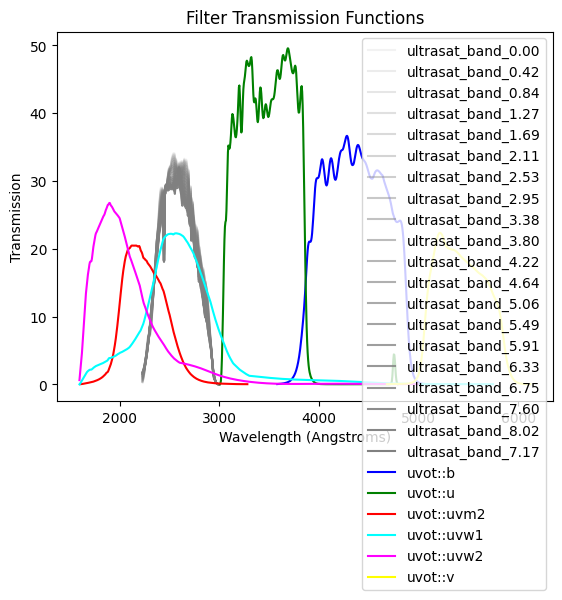

In [3]:
import sncosmo
import matplotlib.pyplot as plt
import numpy as np

# Define the band lists
ultrasat_bands = [
    "ultrasat_band_0.00", "ultrasat_band_0.42", "ultrasat_band_0.84",
    "ultrasat_band_1.27", "ultrasat_band_1.69", "ultrasat_band_2.11",
    "ultrasat_band_2.53", "ultrasat_band_2.95", "ultrasat_band_3.38",
    "ultrasat_band_3.80", "ultrasat_band_4.22", "ultrasat_band_4.64",
    "ultrasat_band_5.06", "ultrasat_band_5.49", "ultrasat_band_5.91",
    "ultrasat_band_6.33", "ultrasat_band_6.75", "ultrasat_band_7.60",
    "ultrasat_band_8.02", "ultrasat_band_7.17"
]

uvot_bands = ['uvot::b', 'uvot::u', 'uvot::uvm2', 'uvot::uvw1', 'uvot::uvw2', 'uvot::v']

# Plot ULTRASAT bands with grey color and varying alpha
alphas = np.linspace(0.1, 1.0, len(ultrasat_bands))
for i, band in enumerate(ultrasat_bands):
    bandpass = sncosmo.get_bandpass(band)
    plt.plot(bandpass.wave, bandpass.trans*100, color='grey', alpha=alphas[i], label=band)

# Plot UVOT bands with different colors
colors = ['blue', 'green', 'red', 'cyan', 'magenta', 'yellow']
for band, color in zip(uvot_bands, colors):
    bandpass = sncosmo.get_bandpass(band)
    plt.plot(bandpass.wave, bandpass.trans, color=color, label=band)

plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Transmission')
plt.title('Filter Transmission Functions')
plt.legend()
plt.show()

In [6]:
# Calculate and print effective wavelength for each filter
all_bands = ultrasat_bands + uvot_bands
for band in all_bands:
    bandpass = sncosmo.get_bandpass(band)
    wave = bandpass.wave
    trans = bandpass.trans
    num = np.trapezoid(wave * trans, wave)
    den = np.trapezoid(trans, wave)
    eff_wavelength = num / den
    print(f"{band}: {eff_wavelength:.2f} Angstroms")

ultrasat_band_0.00: 2594.47 Angstroms
ultrasat_band_0.42: 2594.45 Angstroms
ultrasat_band_0.84: 2594.36 Angstroms
ultrasat_band_1.27: 2593.99 Angstroms
ultrasat_band_1.69: 2593.63 Angstroms
ultrasat_band_2.11: 2593.74 Angstroms
ultrasat_band_2.53: 2593.27 Angstroms
ultrasat_band_2.95: 2592.25 Angstroms
ultrasat_band_3.38: 2591.53 Angstroms
ultrasat_band_3.80: 2591.70 Angstroms
ultrasat_band_4.22: 2589.98 Angstroms
ultrasat_band_4.64: 2590.20 Angstroms
ultrasat_band_5.06: 2589.24 Angstroms
ultrasat_band_5.49: 2587.34 Angstroms
ultrasat_band_5.91: 2586.12 Angstroms
ultrasat_band_6.33: 2586.49 Angstroms
ultrasat_band_6.75: 2585.26 Angstroms
ultrasat_band_7.60: 2581.35 Angstroms
ultrasat_band_8.02: 2581.92 Angstroms
ultrasat_band_7.17: 2582.82 Angstroms
uvot::b: 4359.05 Angstroms
uvot::u: 3475.48 Angstroms
uvot::uvm2: 2254.86 Angstroms
uvot::uvw1: 2614.07 Angstroms
uvot::uvw2: 2079.02 Angstroms
uvot::v: 5430.12 Angstroms


/var/folders/w_/hyfkyntj02s_3xtw61hfztxw0000gn/T/ipykernel_28211/1002710126.py:4: UserWarning: Input line 38 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  data = np.loadtxt('/Users/qinanwang/data/swift/SN2023bee_uvotB25.0.dat', skiprows=37, dtype=str)


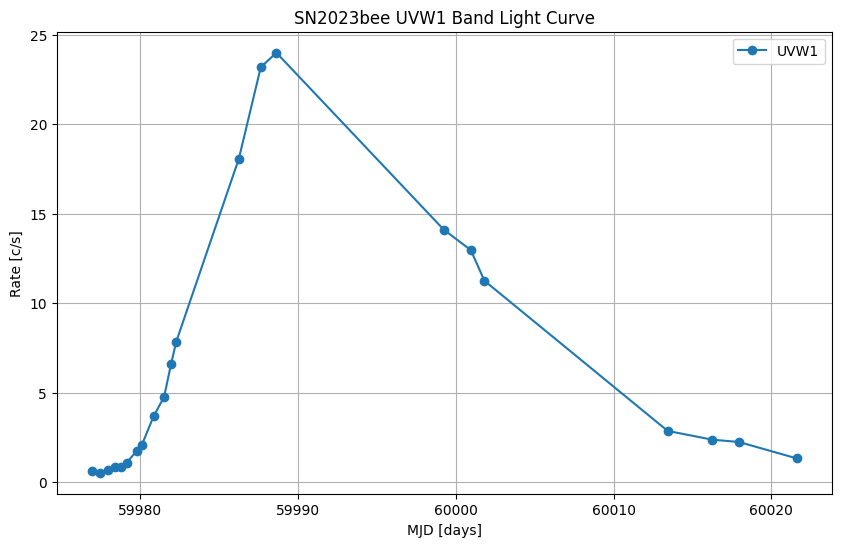

In [8]:
import numpy as np

# Read the data file using numpy, skipping header
data = np.loadtxt('/Users/qinanwang/data/swift/SN2023bee_uvotB25.0.dat', skiprows=37, dtype=str)

# Filter for UVW1 band (column 0 is Filter)
uvw1_mask = data[:, 0] == 'UVW1'
uvw1_data = data[uvw1_mask]

# Extract MJD and Rate
mjd = uvw1_data[:, 1].astype(float)
rate = uvw1_data[:, 6].astype(float)

# Plot MJD vs Rate
plt.figure(figsize=(10, 6))
plt.plot(mjd, rate, 'o-', label='UVW1')
plt.xlabel('MJD [days]')
plt.ylabel('Rate [c/s]')
plt.title('SN2023bee UVW1 Band Light Curve')
plt.legend()
plt.grid(True)
plt.show()

/var/folders/w_/hyfkyntj02s_3xtw61hfztxw0000gn/T/ipykernel_41573/410525740.py:35: UserWarning: genfromtxt: Empty input file: "/Users/qinanwang/data/swift/SNF20080720001_uvotB15.1.dat"
  raw = np.genfromtxt(filepath, skip_header=37, dtype=str, filling_values='NULL', invalid_raise=False)


/var/folders/w_/hyfkyntj02s_3xtw61hfztxw0000gn/T/ipykernel_41573/410525740.py:35: UserWarning: genfromtxt: Empty input file: "/Users/qinanwang/data/swift/SNF20080720001_uvotB15.1.dat"
  raw = np.genfromtxt(filepath, skip_header=37, dtype=str, filling_values='NULL', invalid_raise=False)


Plotted 69 SNe
Plot generated


/var/folders/w_/hyfkyntj02s_3xtw61hfztxw0000gn/T/ipykernel_41573/410525740.py:35: UserWarning: genfromtxt: Empty input file: "/Users/qinanwang/data/swift/SNF20080720001_uvotB15.1.dat"
  raw = np.genfromtxt(filepath, skip_header=37, dtype=str, filling_values='NULL', invalid_raise=False)


Plotted 69 SNe
Plot generated


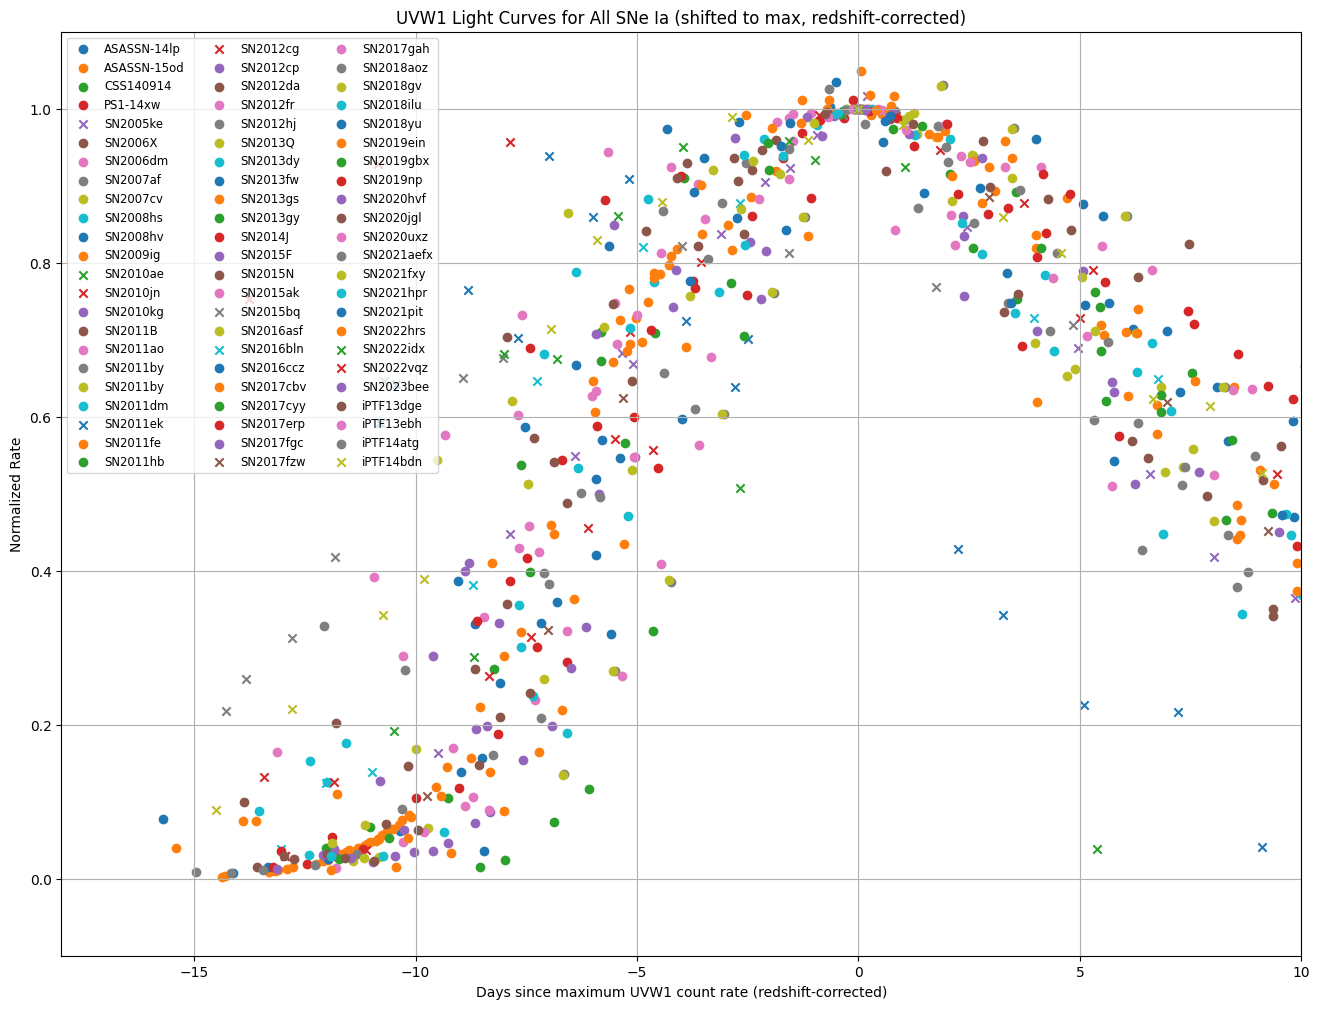

Objects where max(rate) > fitted peak_rate:
ASASSN-15hy
SN2005ke
SN2007S
SN2007af
SN2008hv
SN2009ig
SN2011by
SN2011by
SN2011fe
SN2011iv
SN2013fw
SN2014J
SN2016ekg
SN2022ywf

Targets ranked by number of datapoints before mjd_max (most to least):
SN2021aefx: 145
SN2011fe: 49
SN2012ht: 27
SN2021hpr: 21
SN2023bee: 14
SN2014J: 12
SN2020jgl: 11
SN2011ek: 10
SN2015bq: 10
SN2005ke: 9
SN2020uxz: 9
SN2021pit: 9
iPTF14bdn: 9
SN2009ig: 8
SN2013fw: 8
SN2016bln: 8
SN2017erp: 8
SN2018ilu: 8
SN2011ao: 7
SN2012fr: 7
SN2015ak: 7
SN2017cbv: 7
SN2019ein: 7
SN2019gbx: 7
SN2019np: 7
SN2020nvb: 7
iPTF13dge: 7
SN2010ae: 6
SN2010jn: 6
SN2011by: 6
SN2011by: 6
SN2012cg: 6
SN2017cyy: 6
SN2018yu: 6
SN2020hvf: 6
iPTF13ebh: 6
ASASSN-14lp: 5
CSS140914: 5
PS1-14xw: 5
SN2005df: 5
SN2006dm: 5
SN2007S: 5
SN2007af: 5
SN2007cv: 5
SN2008hv: 5
SN2009Y: 5
SN2010kg: 5
SN2011dm: 5
SN2013gs: 5
SN2013gy: 5
SN2015N: 5
SN2018gv: 5
SN2021fxy: 5
SN2021jad: 5
SN2022vqz: 5
ASASSN-13ch: 4
ASASSN-15so: 4
ASASSN-15tj: 4
LSQ13ry: 4
SN2005c

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the list of light curves
list_file = '/Users/qinanwang/data/swift/Swift_Ia_light_curves_list.csv'
lc_list = pd.read_csv(list_file)

# Directory for data files
data_dir = '/Users/qinanwang/data/swift/'

# Initialize plot
plt.figure(figsize=(16, 12))

# List to collect objects where the fit peak is below the observed max
objects_peak_below_max = []

# Counter for plotted SNe
plotted_count = 0

# Loop over each supernova
for idx, row in lc_list.iterrows():
    sn_name = row['SNname']
    filename = row['data_file']
    filepath = data_dir + filename
    redshift = row['redshift']
    objtype = row['type']

    try:
        # Read the data file using numpy, skipping header rows
        # Use genfromtxt to handle irregular/missing values (NULL, empty lines, etc.)
        raw = np.genfromtxt(filepath, skip_header=37, dtype=str, filling_values='NULL', invalid_raise=False)
        if raw.size == 0:
            continue

        # Ensure we have a 2D array (single-row files can come back as 1D)
        if raw.ndim == 1:
            raw = raw.reshape(1, -1)

        # Need at least 7 columns for the values we use
        if raw.shape[1] < 7:
            continue

        # Filter for UVW1 band (column 0 is Filter)
        uvw1_mask = raw[:, 0] == 'UVW1'
        uvw1_data = raw[uvw1_mask]
        if uvw1_data.size == 0:
            continue  # No UVW1 data

        # Extract MJD and Rate as strings
        mjd_str = uvw1_data[:, 1]
        rate_str = uvw1_data[:, 6]

        # Filter out invalid/NULL entries
        valid_mask = (rate_str != 'NULL') & (mjd_str != 'NULL')
        if not np.any(valid_mask):
            continue

        mjd = mjd_str[valid_mask].astype(float)
        rate = rate_str[valid_mask].astype(float)

        # Sort by MJD
        sort_indices = np.argsort(mjd)
        mjd = mjd[sort_indices]
        rate = rate[sort_indices]

        # Find the MJD of maximum rate
        max_idx = np.argmax(rate)
        initial_mjd_max = mjd[max_idx]

        # First attempt: fit a parabola to all points within [-5, +5] days (redshift-corrected)
        mjd_shifted_init = (mjd - initial_mjd_max) / (1 + redshift)
        in_window = np.abs(mjd_shifted_init) <= 3
        if np.count_nonzero(in_window) >= 3:
            x = mjd_shifted_init[in_window]
            y = rate[in_window]

            # Fit quadratic: y = a*x^2 + b*x + c
            a, b, c = np.polyfit(x, y, 2)
            if a < 0:
                mjd_shifted_peak = -b / (2 * a)
                peak_rate = np.polyval([a, b, c], mjd_shifted_peak)
                mjd_max = initial_mjd_max + mjd_shifted_peak * (1 + redshift)
            else:
                # Fallback to simple maximum if parabola isn't concave down
                mjd_max = initial_mjd_max
                peak_rate = rate[max_idx]
        else:
            # Fallback: fit a parabola to the 3 points around the maximum
            if 0 < max_idx < len(rate) - 1:
                x0, x1, x2 = mjd[max_idx-1], mjd[max_idx], mjd[max_idx+1]
                y0, y1, y2 = rate[max_idx-1], rate[max_idx], rate[max_idx+1]
                dx0 = x0 - x1
                dx2 = x2 - x1
                denom = dx0 * dx2 * (dx0 - dx2)
                if denom != 0:
                    a = (dx2 * (y0 - y1) - dx0 * (y2 - y1)) / denom
                    if a < 0:  # ensure it's a maximum
                        b = ((y0 - y1) - a * dx0**2) / dx0
                        mjd_max = x1 - b / (2 * a)
                        peak_rate = y1 - b**2 / (4 * a)
                    else:
                        mjd_max = x1
                        peak_rate = y1
                else:
                    mjd_max = x1
                    peak_rate = y1
            else:
                mjd_max = mjd[max_idx]
                peak_rate = rate[max_idx]

        # Guard against non-positive peak_rate
        if peak_rate <= 0 or np.isnan(peak_rate):
            peak_rate = rate[max_idx]

        # Shift MJD so that max is at 0 and correct for redshift
        mjd_shifted = (mjd - mjd_max) / (1 + redshift)

        # If the fitted peak is below the observed maximum, record for inspection
        if np.max(rate) > peak_rate:
            objects_peak_below_max.append(sn_name)

        # Only plot if there are at least 2 points in the range -30 < mjd_shifted < -5
        mid_range_mask = (mjd_shifted > -30) & (mjd_shifted < -5)
        if np.count_nonzero(mid_range_mask) < 2:
            continue

        # Plot with thin line, no markers to avoid clutter
        if objtype == 'Ia':
            plt.scatter(mjd_shifted, rate / peak_rate, marker='o', label=sn_name)
        else:
            plt.scatter(mjd_shifted, rate / peak_rate, marker='x', label=sn_name)
        plotted_count += 1

    except Exception as e:
        print(f"Error processing {sn_name}: {e}")
        continue

plt.ylim(-0.1, 1.1)
plt.xlim(-18, 10)  # Removed to show all data
plt.xlabel('Days since maximum UVW1 count rate (redshift-corrected)')
plt.ylabel('Normalized Rate')
plt.title('UVW1 Light Curves for All SNe Ia (shifted to max, redshift-corrected)')
plt.legend(loc='upper left', fontsize='small', ncol=3)
plt.grid(True)
print(f"Plotted {plotted_count} SNe")
print("Plot generated")
plt.show()

# Print the list of objects where the fitted peak is below the observed maximum
print("Objects where max(rate) > fitted peak_rate:")
for obj in objects_peak_below_max:
    print(obj)

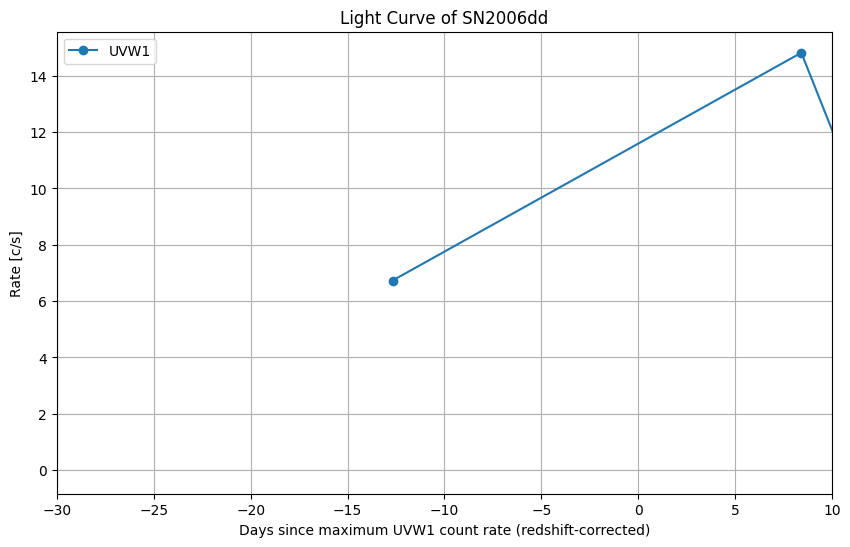

In [75]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming lc_list and data_dir are defined from previous cells
# Find the row for SN 2011fe
sn_row = lc_list[lc_list['SNname'] == 'SN2006dd'].iloc[0]
sn_name = sn_row['SNname']
filename = sn_row['data_file']
filepath = data_dir + filename
redshift = sn_row['redshift']

# Read the data file using genfromtxt to handle missing / NULL values
raw = np.genfromtxt(filepath, skip_header=37, dtype=str, filling_values='NULL', invalid_raise=False)
if raw.size == 0:
    raise RuntimeError(f"No data found in {filepath}")

# Ensure 2D array
if raw.ndim == 1:
    raw = raw.reshape(1, -1)

# Need at least 7 columns (filter, MJD, ..., rate column)
if raw.shape[1] < 7:
    raise RuntimeError(f"Unexpected file format for {filepath}")

# Filter for UVW1 band
uvw1_mask = raw[:, 0] == 'UVW1'
uvw1_data = raw[uvw1_mask]
if uvw1_data.size == 0:
    raise RuntimeError(f"No UVW1 data found in {filepath}")

# Extract MJD and Rate as strings
mjd_str = uvw1_data[:, 1]
rate_str = uvw1_data[:, 6]

# Filter out invalid/NULL entries
valid_mask = (rate_str != 'NULL') & (mjd_str != 'NULL')
if not np.any(valid_mask):
    raise RuntimeError(f"No valid MJD/rate values in {filepath}")

mjd = mjd_str[valid_mask].astype(float)
rate = rate_str[valid_mask].astype(float)

# Sort by MJD
sort_indices = np.argsort(mjd)
mjd = mjd[sort_indices]
rate = rate[sort_indices]

# Find the MJD of maximum rate using quadratic interpolation
max_idx = np.argmax(rate)
peak_rate = rate[max_idx]
if 0 < max_idx < len(rate) - 1:
    x0, x1, x2 = mjd[max_idx-1], mjd[max_idx], mjd[max_idx+1]
    y0, y1, y2 = rate[max_idx-1], rate[max_idx], rate[max_idx+1]
    dx0 = x0 - x1
    dx2 = x2 - x1
    denom = dx0 * dx2 * (dx0 - dx2)
    if denom != 0:
        a = (dx2 * (y0 - y1) - dx0 * (y2 - y1)) / denom
        if a < 0:  # ensure it's a maximum
            b = ((y0 - y1) - a * dx0**2) / dx0
            mjd_max = x1 - b / (2 * a)
            peak_rate = y1 - b**2 / (4 * a)
        else:
            mjd_max = x1
            peak_rate = y1
    else:
        mjd_max = x1
        peak_rate = y1
else:
    mjd_max = mjd[max_idx]
    peak_rate = rate[max_idx]

# Shift MJD so that max is at 0 and correct for redshift
mjd_shifted = (mjd - mjd_max) / (1 + redshift)
# Plot the light curve
plt.figure(figsize=(10, 6))
plt.plot(mjd_shifted, rate, 'o-', label='UVW1')
plt.xlabel('Days since maximum UVW1 count rate (redshift-corrected)')
plt.ylabel('Rate [c/s]')
plt.xlim(-30, 10)
plt.title(f'Light Curve of {sn_name}')
plt.legend()
plt.grid(True)
plt.show()

ASASSN-14lp: stretch = 6.211, mjd_max = 57011.805
SN2009ig: stretch = 6.070, mjd_max = 55076.578
SN2010ae: stretch = 7.653, mjd_max = 55262.555
SN2010jn: stretch = 12.352, mjd_max = 55499.677
SN2011by: stretch = 6.106, mjd_max = 55688.137
SN2011by: stretch = 6.107, mjd_max = 55688.132
SN2011fe: stretch = 6.357, mjd_max = 55812.370
SN2012cg: stretch = 6.577, mjd_max = 56079.291
SN2012cp: stretch = 8.080, mjd_max = 56080.383
SN2012fr: stretch = 6.332, mjd_max = 56240.277
SN2013gy: stretch = 6.271, mjd_max = 56646.169
SN2014J: stretch = 7.388, mjd_max = 56688.444
SN2015F: stretch = 7.188, mjd_max = 57105.028
SN2015N: stretch = 9.068, mjd_max = 57223.513
SN2015ak: stretch = 9.212, mjd_max = 57266.507
SN2015bq: stretch = 10.439, mjd_max = 57082.350
SN2016bln: stretch = 7.343, mjd_max = 57495.869
SN2016ccz: stretch = 6.347, mjd_max = 57537.743
SN2017cbv: stretch = 7.134, mjd_max = 57838.035
SN2017cyy: stretch = 5.937, mjd_max = 57867.834
SN2017erp: stretch = 6.744, mjd_max = 57933.286
SN2017

ASASSN-14lp: stretch = 6.211, mjd_max = 57011.805
SN2009ig: stretch = 6.070, mjd_max = 55076.578
SN2010ae: stretch = 7.653, mjd_max = 55262.555
SN2010jn: stretch = 12.352, mjd_max = 55499.677
SN2011by: stretch = 6.106, mjd_max = 55688.137
SN2011by: stretch = 6.107, mjd_max = 55688.132
SN2011fe: stretch = 6.357, mjd_max = 55812.370
SN2012cg: stretch = 6.577, mjd_max = 56079.291
SN2012cp: stretch = 8.080, mjd_max = 56080.383
SN2012fr: stretch = 6.332, mjd_max = 56240.277
SN2013gy: stretch = 6.271, mjd_max = 56646.169
SN2014J: stretch = 7.388, mjd_max = 56688.444
SN2015F: stretch = 7.188, mjd_max = 57105.028
SN2015N: stretch = 9.068, mjd_max = 57223.513
SN2015ak: stretch = 9.212, mjd_max = 57266.507
SN2015bq: stretch = 10.439, mjd_max = 57082.350
SN2016bln: stretch = 7.343, mjd_max = 57495.869
SN2016ccz: stretch = 6.347, mjd_max = 57537.743
SN2017cbv: stretch = 7.134, mjd_max = 57838.035
SN2017cyy: stretch = 5.937, mjd_max = 57867.834
SN2017erp: stretch = 6.744, mjd_max = 57933.286
SN2017

/var/folders/w_/hyfkyntj02s_3xtw61hfztxw0000gn/T/ipykernel_41573/202509363.py:63: UserWarning: genfromtxt: Empty input file: "/Users/qinanwang/data/swift/SNF20080720001_uvotB15.1.dat"
  raw = np.genfromtxt(filepath, skip_header=37, dtype=str, filling_values='NULL', invalid_raise=False)


ASASSN-14lp: stretch = 6.211, mjd_max = 57011.805
SN2009ig: stretch = 6.070, mjd_max = 55076.578
SN2010ae: stretch = 7.653, mjd_max = 55262.555
SN2010jn: stretch = 12.352, mjd_max = 55499.677
SN2011by: stretch = 6.106, mjd_max = 55688.137
SN2011by: stretch = 6.107, mjd_max = 55688.132
SN2011fe: stretch = 6.357, mjd_max = 55812.370
SN2012cg: stretch = 6.577, mjd_max = 56079.291
SN2012cp: stretch = 8.080, mjd_max = 56080.383
SN2012fr: stretch = 6.332, mjd_max = 56240.277
SN2013gy: stretch = 6.271, mjd_max = 56646.169
SN2014J: stretch = 7.388, mjd_max = 56688.444
SN2015F: stretch = 7.188, mjd_max = 57105.028
SN2015N: stretch = 9.068, mjd_max = 57223.513
SN2015ak: stretch = 9.212, mjd_max = 57266.507
SN2015bq: stretch = 10.439, mjd_max = 57082.350
SN2016bln: stretch = 7.343, mjd_max = 57495.869
SN2016ccz: stretch = 6.347, mjd_max = 57537.743
SN2017cbv: stretch = 7.134, mjd_max = 57838.035
SN2017cyy: stretch = 5.937, mjd_max = 57867.834
SN2017erp: stretch = 6.744, mjd_max = 57933.286
SN2017

/var/folders/w_/hyfkyntj02s_3xtw61hfztxw0000gn/T/ipykernel_41573/202509363.py:63: UserWarning: genfromtxt: Empty input file: "/Users/qinanwang/data/swift/SNF20080720001_uvotB15.1.dat"
  raw = np.genfromtxt(filepath, skip_header=37, dtype=str, filling_values='NULL', invalid_raise=False)


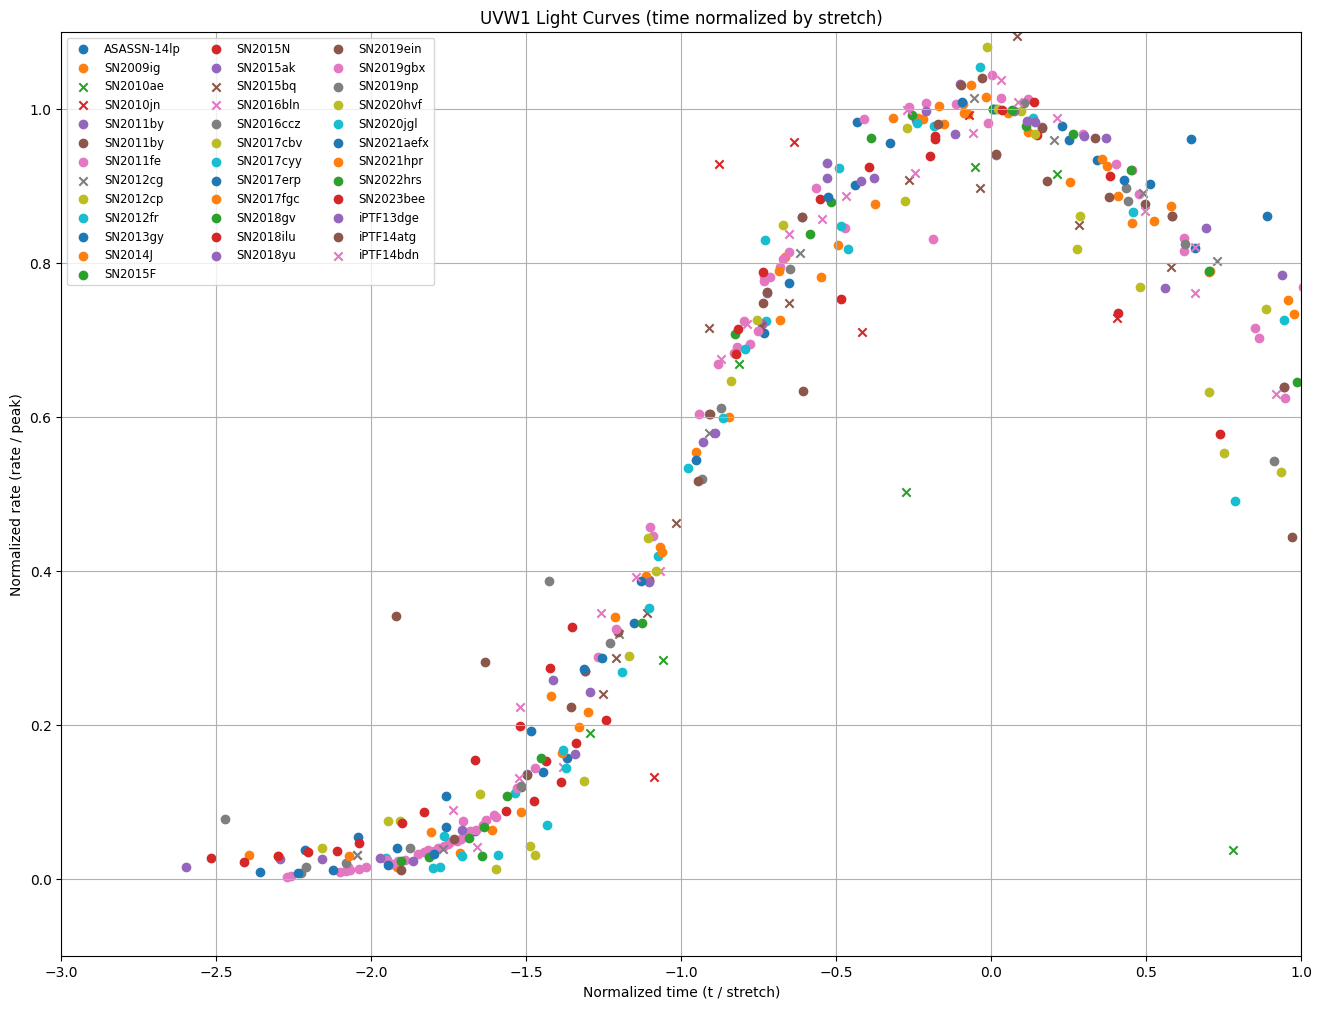

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import brentq


# Function to compute stretch (time interval between half-max points using scipy)
def compute_stretch(mjd_shifted, rate, peak_rate, return_rise = False):
    half = peak_rate / 2.0
    peak_idx = np.argmax(rate)
    
    # Create a cubic spline interpolation
    try:
        f = interp1d(mjd_shifted, rate, kind='cubic', fill_value='extrapolate')
    except:
        # Fallback to linear if cubic fails
        f = interp1d(mjd_shifted, rate, kind='linear', fill_value='extrapolate')
    
    # Define function for root finding: f(t) - half
    def diff_func(t):
        return f(t) - half
    
    rise_cross = None
    fall_cross = None
    
    # Find rising side crossing (before peak)
    try:
        # Find a bracket where the function changes sign
        for i in range(peak_idx):
            if (rate[i] - half) * (rate[i + 1] - half) < 0:
                rise_cross = brentq(diff_func, mjd_shifted[i], mjd_shifted[i + 1])
                break
    except:
        pass
    
    # Find falling side crossing (after peak)
    try:
        for i in range(peak_idx, len(rate) - 1):
            if (rate[i] - half) * (rate[i + 1] - half) < 0:
                fall_cross = brentq(diff_func, mjd_shifted[i], mjd_shifted[i + 1])
                break
    except:
        pass
    
    if rise_cross is None or fall_cross is None:
        return None
    if return_rise:
        return  abs(rise_cross)
    return fall_cross - rise_cross

plt.figure(figsize=(16, 12))
plotted_count = 0

for idx, row in lc_list.iterrows():
    sn_name = row['SNname']
    filename = row['data_file']
    filepath = data_dir + filename
    redshift = row['redshift']
    objtype = row['type']

    try:
        raw = np.genfromtxt(filepath, skip_header=37, dtype=str, filling_values='NULL', invalid_raise=False)
        if raw.size == 0:
            continue
        if raw.ndim == 1:
            raw = raw.reshape(1, -1)
        if raw.shape[1] < 7:
            continue

        uvw1_mask = raw[:, 0] == 'UVW1'
        uvw1_data = raw[uvw1_mask]
        if uvw1_data.size == 0:
            continue

        mjd_str = uvw1_data[:, 1]
        rate_str = uvw1_data[:, 6]
        valid_mask = (rate_str != 'NULL') & (mjd_str != 'NULL')
        if not np.any(valid_mask):
            continue

        mjd = mjd_str[valid_mask].astype(float)
        rate = rate_str[valid_mask].astype(float)
        sort_idx = np.argsort(mjd)
        mjd = mjd[sort_idx]
        rate = rate[sort_idx]

        # Determine max and shift
        max_idx = np.argmax(rate)
        initial_mjd_max = mjd[max_idx]

        mjd_shifted_init = (mjd - initial_mjd_max) / (1 + redshift)
        in_window = np.abs(mjd_shifted_init) <= 5

        if np.count_nonzero(in_window) >= 3:
            x = mjd_shifted_init[in_window]
            y = rate[in_window]
            a, b, c = np.polyfit(x, y, 2)
            if a < 0:
                mjd_shifted_peak = -b / (2 * a)
                peak_rate = np.polyval([a, b, c], mjd_shifted_peak)
                mjd_max = initial_mjd_max + mjd_shifted_peak * (1 + redshift)
        #    else:
        #        mjd_max = initial_mjd_max
        #        peak_rate = rate[max_idx]

        if np.count_nonzero(in_window) < 3 or a >=0:
            # Fallback to 3-point fit
            if 0 < max_idx < len(rate) - 1:
                x0, x1, x2 = mjd[max_idx - 1], mjd[max_idx], mjd[max_idx + 1]
                y0, y1, y2 = rate[max_idx - 1], rate[max_idx], rate[max_idx + 1]
                dx0 = x0 - x1
                dx2 = x2 - x1
                denom = dx0 * dx2 * (dx0 - dx2)
                if denom != 0:
                    a = (dx2 * (y0 - y1) - dx0 * (y2 - y1)) / denom
                    if a < 0:
                        b = ((y0 - y1) - a * dx0**2) / dx0
                        mjd_max = x1 - b / (2 * a)
                        peak_rate = y1 - b**2 / (4 * a)
                    else:
                        mjd_max = x1
                        peak_rate = y1
                else:
                    mjd_max = x1
                    peak_rate = y1
            else:
                mjd_max = mjd[max_idx]
                peak_rate = rate[max_idx]

        if peak_rate <= 0 or np.isnan(peak_rate):
            peak_rate = rate[max_idx]

        mjd_shifted = (mjd - mjd_max) / (1 + redshift)

        mid_range_mask = (mjd_shifted > -30) & (mjd_shifted < -8)
        if np.count_nonzero(mid_range_mask) < 2:
            continue

        stretch = compute_stretch(mjd_shifted, rate, peak_rate, return_rise = True)
        if stretch is None or stretch <= 0:
            continue

        print(f"{sn_name}: stretch = {stretch:.3f}, mjd_max = {mjd_max:.3f}")

        # Normalize time by stretch, and normalize rate by peak
        t_norm = mjd_shifted / stretch
        y_norm = rate / peak_rate

        mid_range_mask = (t_norm > -3) & (t_norm < 3)
        if np.count_nonzero(mid_range_mask) < 2:
            continue

        # Only plot if there are at least 2 points in the range -30 < mjd_shifted < -5

        if objtype == 'Ia':
            plt.scatter(t_norm[mid_range_mask], y_norm[mid_range_mask], marker='o', label=sn_name)
        else:
            plt.scatter(t_norm[mid_range_mask], y_norm[mid_range_mask], marker='x', label=sn_name)
        plotted_count += 1

    except Exception:
        continue

plt.ylim(-0.1, 1.1)
plt.xlim(-3, 1)  # Removed to show all data

plt.xlabel('Normalized time (t / stretch)')
plt.ylabel('Normalized rate (rate / peak)')
plt.title('UVW1 Light Curves (time normalized by stretch)')
plt.legend(loc='upper left', fontsize='small', ncol=3)
plt.grid(True)
print(f"Plotted {plotted_count} SNe")
plt.show()

SN SN2011fe Diagnostic Check:
  Peak Rate: 384.769 c/s
  Peak Time (mjd_max): 55812.370
  Rise Crossing (t at half-max): -6.357
  Fall Crossing (t at half-max): 7.394
  Stretch (fall - rise): 13.751


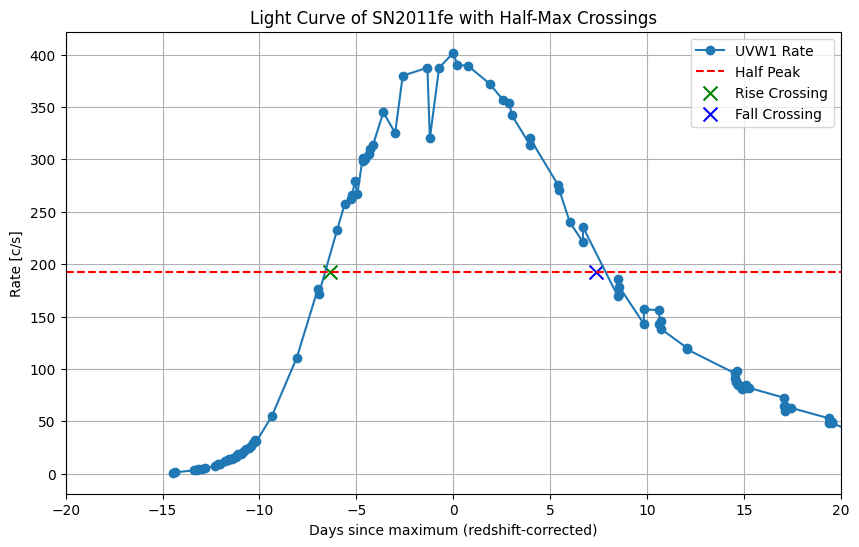

In [6]:
# Diagnostic check for SN2006dd
sn_target = 'SN2011fe'
sn_row = lc_list[lc_list['SNname'] == sn_target].iloc[0]
sn_name = sn_row['SNname']
filename = sn_row['data_file']
filepath = data_dir + filename
redshift = sn_row['redshift']

# Read the data file
raw = np.genfromtxt(filepath, skip_header=37, dtype=str, filling_values='NULL', invalid_raise=False)
if raw.ndim == 1:
    raw = raw.reshape(1, -1)

uvw1_mask = raw[:, 0] == 'UVW1'
uvw1_data = raw[uvw1_mask]
mjd_str = uvw1_data[:, 1]
rate_str = uvw1_data[:, 6]
valid_mask = (rate_str != 'NULL') & (mjd_str != 'NULL')

mjd = mjd_str[valid_mask].astype(float)
rate = rate_str[valid_mask].astype(float)
sort_idx = np.argsort(mjd)
mjd = mjd[sort_idx]
rate = rate[sort_idx]

# Determine peak
max_idx = np.argmax(rate)
initial_mjd_max = mjd[max_idx]

mjd_shifted_init = (mjd - initial_mjd_max) / (1 + redshift)
in_window = np.abs(mjd_shifted_init) <= 5

if np.count_nonzero(in_window) >= 3:
    x = mjd_shifted_init[in_window]
    y = rate[in_window]
    a, b, c = np.polyfit(x, y, 2)
    if a < 0:
        mjd_shifted_peak = -b / (2 * a)
        peak_rate = np.polyval([a, b, c], mjd_shifted_peak)
        mjd_max = initial_mjd_max + mjd_shifted_peak * (1 + redshift)
#    else:
#        mjd_max = initial_mjd_max
#        peak_rate = rate[max_idx]
if np.count_nonzero(in_window) < 3 or a >=0:
    if 0 < max_idx < len(rate) - 1:
        x0, x1, x2 = mjd[max_idx - 1], mjd[max_idx], mjd[max_idx + 1]
        y0, y1, y2 = rate[max_idx - 1], rate[max_idx], rate[max_idx + 1]
        dx0 = x0 - x1
        dx2 = x2 - x1
        denom = dx0 * dx2 * (dx0 - dx2)
        if denom != 0 and (dx2 * (y0 - y1) - dx0 * (y2 - y1)) / denom < 0:
            a = (dx2 * (y0 - y1) - dx0 * (y2 - y1)) / denom
            b = ((y0 - y1) - a * dx0**2) / dx0
            mjd_max = x1 - b / (2 * a)
            peak_rate = y1 - b**2 / (4 * a)
        else:
            mjd_max = x1
            peak_rate = y1
    else:
        mjd_max = mjd[max_idx]
        peak_rate = rate[max_idx]

mjd_shifted = (mjd - mjd_max) / (1 + redshift)

# Find half-max crossings
half = peak_rate / 2.0
peak_idx = np.argmax(rate)

try:
    f = interp1d(mjd_shifted, rate, kind='cubic', fill_value='extrapolate')
except:
    f = interp1d(mjd_shifted, rate, kind='linear', fill_value='extrapolate')

def diff_func(t):
    return f(t) - half

rise_cross = None
fall_cross = None

try:
    for i in range(peak_idx):
        if (rate[i] - half) * (rate[i + 1] - half) < 0:
            rise_cross = brentq(diff_func, mjd_shifted[i], mjd_shifted[i + 1])
            break
except:
    pass

try:
    for i in range(peak_idx, len(rate) - 1):
        if (rate[i] - half) * (rate[i + 1] - half) < 0:
            fall_cross = brentq(diff_func, mjd_shifted[i], mjd_shifted[i + 1])
            break
except:
    pass

print(f"SN {sn_target} Diagnostic Check:")
print(f"  Peak Rate: {peak_rate:.3f} c/s")
print(f"  Peak Time (mjd_max): {mjd_max:.3f}")
print(f"  Rise Crossing (t at half-max): {rise_cross:.3f}" if rise_cross is not None else "  Rise Crossing: None")
print(f"  Fall Crossing (t at half-max): {fall_cross:.3f}" if fall_cross is not None else "  Fall Crossing: None")
if rise_cross is not None and fall_cross is not None:
    stretch = fall_cross - rise_cross
    print(f"  Stretch (fall - rise): {stretch:.3f}")

In [ ]:
  Peak Rate: 24.024 c/s
  Peak Time (mjd_max): 59988.475
  Rise Crossing (t at half-max): -4.549
  Fall Crossing (t at half-max): 12.901
  Stretch (fall - rise): 17.450

SN SN2011fe Diagnostic Check:
  Peak Rate: 384.769 c/s
  Peak Time (mjd_max): 55812.370
  Rise Crossing (t at half-max): -6.357
  Fall Crossing (t at half-max): 7.394
  Stretch (fall - rise): 13.751

/var/folders/w_/hyfkyntj02s_3xtw61hfztxw0000gn/T/ipykernel_41573/3170086778.py:62: UserWarning: genfromtxt: Empty input file: "/Users/qinanwang/data/swift/SNF20080720001_uvotB15.1.dat"
  raw = np.genfromtxt(filepath, skip_header=37, dtype=str, filling_values='NULL', invalid_raise=False)


SN2021aefx: stretch = 6.486, mjd_max = 59545.132
SN2011fe: stretch = 6.357, mjd_max = 55812.370
SN2021hpr: stretch = 5.184, mjd_max = 59319.318
SN2023bee: stretch = 4.549, mjd_max = 59988.475
SN2014J: stretch = 7.388, mjd_max = 56688.444
SN2020jgl: stretch = 8.356, mjd_max = 58992.553
SN2009ig: stretch = 6.070, mjd_max = 55076.578
SN2015bq: stretch = 10.439, mjd_max = 57082.350
iPTF14bdn: stretch = 7.971, mjd_max = 56818.825
SN2011by: stretch = 6.106, mjd_max = 55688.137
SN2011by: stretch = 6.106, mjd_max = 55688.137
SN2017erp: stretch = 6.744, mjd_max = 57933.286
SN2018ilu: stretch = 8.636, mjd_max = 58450.185
SN2019gbx: stretch = 4.512, mjd_max = 58643.200
SN2012cg: stretch = 6.577, mjd_max = 56079.291
SN2012fr: stretch = 6.332, mjd_max = 56240.277
SN2015ak: stretch = 9.212, mjd_max = 57266.507
SN2016bln: stretch = 7.343, mjd_max = 57495.869
SN2017cbv: stretch = 7.134, mjd_max = 57838.035
SN2019ein: stretch = 6.119, mjd_max = 58617.182
Plotted 20 SNe


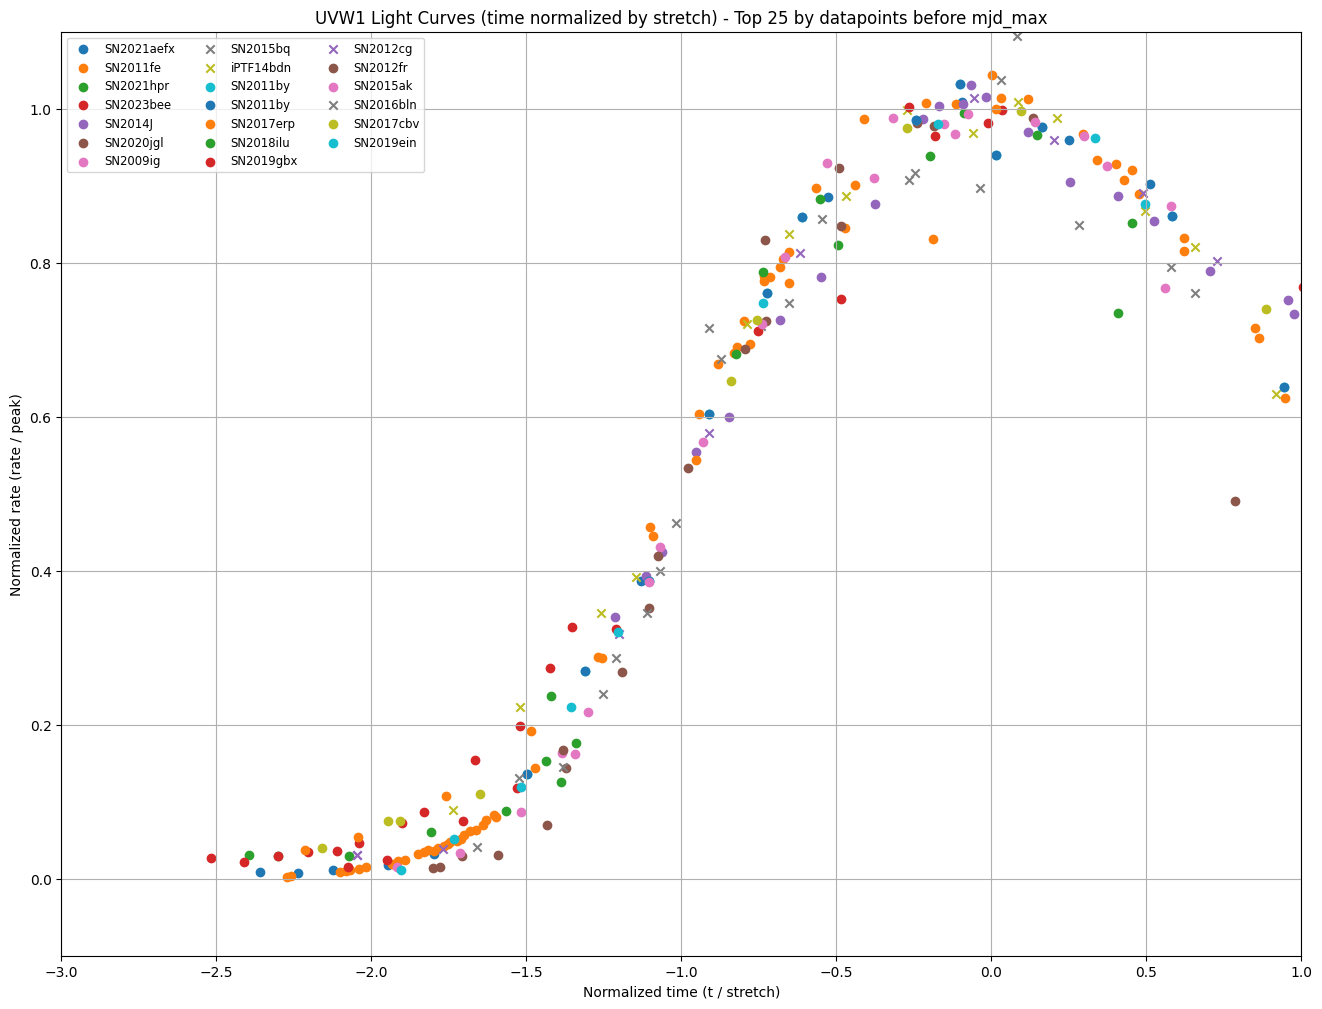

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import brentq


# Function to compute stretch (time interval between half-max points using scipy)
def compute_stretch(mjd_shifted, rate, peak_rate, return_rise = False):
    half = peak_rate / 2.0
    peak_idx = np.argmax(rate)
    
    # Create a cubic spline interpolation
    try:
        f = interp1d(mjd_shifted, rate, kind='cubic', fill_value='extrapolate')
    except:
        # Fallback to linear if cubic fails
        f = interp1d(mjd_shifted, rate, kind='linear', fill_value='extrapolate')
    
    # Define function for root finding: f(t) - half
    def diff_func(t):
        return f(t) - half
    
    rise_cross = None
    fall_cross = None
    
    # Find rising side crossing (before peak)
    try:
        # Find a bracket where the function changes sign
        for i in range(peak_idx):
            if (rate[i] - half) * (rate[i + 1] - half) < 0:
                rise_cross = brentq(diff_func, mjd_shifted[i], mjd_shifted[i + 1])
                break
    except:
        pass
    
    # Find falling side crossing (after peak)
    try:
        for i in range(peak_idx, len(rate) - 1):
            if (rate[i] - half) * (rate[i + 1] - half) < 0:
                fall_cross = brentq(diff_func, mjd_shifted[i], mjd_shifted[i + 1])
                break
    except:
        pass
    
    if rise_cross is None or fall_cross is None:
        return None
    if return_rise:
        return  abs(rise_cross)
    return fall_cross - rise_cross

# First, collect datapoints before mjd_max for all SNe to select top 25
datapoints_before_max = []

for idx, row in lc_list.iterrows():
    sn_name = row['SNname']
    filename = row['data_file']
    filepath = data_dir + filename
    redshift = row['redshift']

    try:
        raw = np.genfromtxt(filepath, skip_header=37, dtype=str, filling_values='NULL', invalid_raise=False)
        if raw.size == 0:
            continue
        if raw.ndim == 1:
            raw = raw.reshape(1, -1)
        if raw.shape[1] < 7:
            continue

        uvw1_mask = raw[:, 0] == 'UVW1'
        uvw1_data = raw[uvw1_mask]
        if uvw1_data.size == 0:
            continue

        mjd_str = uvw1_data[:, 1]
        rate_str = uvw1_data[:, 6]
        valid_mask = (rate_str != 'NULL') & (mjd_str != 'NULL')
        if not np.any(valid_mask):
            continue

        mjd = mjd_str[valid_mask].astype(float)
        rate = rate_str[valid_mask].astype(float)
        sort_idx = np.argsort(mjd)
        mjd = mjd[sort_idx]
        rate = rate[sort_idx]

        # Determine max and shift
        max_idx = np.argmax(rate)
        initial_mjd_max = mjd[max_idx]

        mjd_shifted_init = (mjd - initial_mjd_max) / (1 + redshift)
        in_window = np.abs(mjd_shifted_init) <= 5

        if np.count_nonzero(in_window) >= 3:
            x = mjd_shifted_init[in_window]
            y = rate[in_window]
            a, b, c = np.polyfit(x, y, 2)
            if a < 0:
                mjd_shifted_peak = -b / (2 * a)
                peak_rate = np.polyval([a, b, c], mjd_shifted_peak)
                mjd_max = initial_mjd_max + mjd_shifted_peak * (1 + redshift)
        if np.count_nonzero(in_window) < 3 or a >=0:
            if 0 < max_idx < len(rate) - 1:
                x0, x1, x2 = mjd[max_idx - 1], mjd[max_idx], mjd[max_idx + 1]
                y0, y1, y2 = rate[max_idx - 1], rate[max_idx], rate[max_idx + 1]
                dx0 = x0 - x1
                dx2 = x2 - x1
                denom = dx0 * dx2 * (dx0 - dx2)
                if denom != 0:
                    a = (dx2 * (y0 - y1) - dx0 * (y2 - y1)) / denom
                    if a < 0:
                        b = ((y0 - y1) - a * dx0**2) / dx0
                        mjd_max = x1 - b / (2 * a)
                        peak_rate = y1 - b**2 / (4 * a)
                    else:
                        mjd_max = x1
                        peak_rate = y1
                else:
                    mjd_max = x1
                    peak_rate = y1
            else:
                mjd_max = mjd[max_idx]
                peak_rate = rate[max_idx]

        if peak_rate <= 0 or np.isnan(peak_rate):
            peak_rate = rate[max_idx]

        mjd_shifted = (mjd - mjd_max) / (1 + redshift)

        # Count datapoints before mjd_max
        count_before = np.sum(mjd_shifted < 0)
        datapoints_before_max.append((sn_name, count_before))

    except Exception:
        continue

# Sort and get top 25
datapoints_before_max.sort(key=lambda x: x[1], reverse=True)
top_25_sn_names = [sn for sn, count in datapoints_before_max[:25]]

plt.figure(figsize=(16, 12))
plotted_count = 0

for sn_name in top_25_sn_names:#['SN2011fe', 'SN2017cbv', 'SN2017erp', 'SN2021aefx', 'SN2023bee']:#
    row = lc_list[lc_list['SNname'] == sn_name].iloc[0]
    filename = row['data_file']
    filepath = data_dir + filename
    redshift = row['redshift']
    objtype = row['type']

    try:
        raw = np.genfromtxt(filepath, skip_header=37, dtype=str, filling_values='NULL', invalid_raise=False)
        if raw.size == 0:
            continue
        if raw.ndim == 1:
            raw = raw.reshape(1, -1)
        if raw.shape[1] < 7:
            continue

        uvw1_mask = raw[:, 0] == 'UVW1'
        uvw1_data = raw[uvw1_mask]
        if uvw1_data.size == 0:
            continue

        mjd_str = uvw1_data[:, 1]
        rate_str = uvw1_data[:, 6]
        valid_mask = (rate_str != 'NULL') & (mjd_str != 'NULL')
        if not np.any(valid_mask):
            continue

        mjd = mjd_str[valid_mask].astype(float)
        rate = rate_str[valid_mask].astype(float)
        sort_idx = np.argsort(mjd)
        mjd = mjd[sort_idx]
        rate = rate[sort_idx]

        # Determine max and shift
        max_idx = np.argmax(rate)
        initial_mjd_max = mjd[max_idx]

        mjd_shifted_init = (mjd - initial_mjd_max) / (1 + redshift)
        in_window = np.abs(mjd_shifted_init) <= 5

        if np.count_nonzero(in_window) >= 3:
            x = mjd_shifted_init[in_window]
            y = rate[in_window]
            a, b, c = np.polyfit(x, y, 2)
            if a < 0:
                mjd_shifted_peak = -b / (2 * a)
                peak_rate = np.polyval([a, b, c], mjd_shifted_peak)
                mjd_max = initial_mjd_max + mjd_shifted_peak * (1 + redshift)
        if np.count_nonzero(in_window) < 3 or a >=0:
            if 0 < max_idx < len(rate) - 1:
                x0, x1, x2 = mjd[max_idx - 1], mjd[max_idx], mjd[max_idx + 1]
                y0, y1, y2 = rate[max_idx - 1], rate[max_idx], rate[max_idx + 1]
                dx0 = x0 - x1
                dx2 = x2 - x1
                denom = dx0 * dx2 * (dx0 - dx2)
                if denom != 0:
                    a = (dx2 * (y0 - y1) - dx0 * (y2 - y1)) / denom
                    if a < 0:
                        b = ((y0 - y1) - a * dx0**2) / dx0
                        mjd_max = x1 - b / (2 * a)
                        peak_rate = y1 - b**2 / (4 * a)
                    else:
                        mjd_max = x1
                        peak_rate = y1
                else:
                    mjd_max = x1
                    peak_rate = y1
            else:
                mjd_max = mjd[max_idx]
                peak_rate = rate[max_idx]

        if peak_rate <= 0 or np.isnan(peak_rate):
            peak_rate = rate[max_idx]

        mjd_shifted = (mjd - mjd_max) / (1 + redshift)

        mid_range_mask = (mjd_shifted > -30) & (mjd_shifted < -8)
        if np.count_nonzero(mid_range_mask) < 2:
            continue

        stretch = compute_stretch(mjd_shifted, rate, peak_rate, return_rise = True)
        if stretch is None or stretch <= 0:
            continue

        print(f"{sn_name}: stretch = {stretch:.3f}, mjd_max = {mjd_max:.3f}")

        # Normalize time by stretch, and normalize rate by peak
        t_norm = mjd_shifted / stretch
        y_norm = rate / peak_rate

        mid_range_mask = (t_norm > -3) & (t_norm < 3)
        if np.count_nonzero(mid_range_mask) < 2:
            continue

        # Only plot if there are at least 2 points in the range -30 < mjd_shifted < -5

        if objtype == 'Ia':
            plt.scatter(t_norm[mid_range_mask], y_norm[mid_range_mask], marker='o', label=sn_name)
        else:
            plt.scatter(t_norm[mid_range_mask], y_norm[mid_range_mask], marker='x', label=sn_name)
        plotted_count += 1

    except Exception:
        continue

plt.ylim(-0.1, 1.1)
plt.xlim(-3, 1)  # Removed to show all data

plt.xlabel('Normalized time (t / stretch)')
plt.ylabel('Normalized rate (rate / peak)')
plt.title('UVW1 Light Curves (time normalized by stretch) - Top 25 by datapoints before mjd_max')
plt.legend(loc='upper left', fontsize='small', ncol=3)
plt.grid(True)
print(f"Plotted {plotted_count} SNe")
plt.show()

In [11]:
top_25_sn_names

['SN2021aefx',
 'SN2011fe',
 'SN2021hpr',
 'SN2023bee',
 'SN2014J',
 'SN2020jgl',
 'SN2009ig',
 'SN2021pit',
 'SN2005ke',
 'SN2015bq',
 'SN2020uxz',
 'iPTF14bdn',
 'SN2011ao',
 'SN2011by',
 'SN2011by',
 'SN2017erp',
 'SN2018ilu',
 'SN2019gbx',
 'SN2012cg',
 'SN2012fr',
 'SN2013fw',
 'SN2015ak',
 'SN2016bln',
 'SN2017cbv',
 'SN2019ein']